### Analysis - Continuous Tracking

In [93]:
import numpy as np
from scipy.signal import correlate, correlation_lags
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import pandas as pd

#### Cross Correlogram

In [94]:

def compute_cross_correlogram(effector_signal, cursor_signal, sampling_rate, max_lag_seconds) -> tuple:
    """Compute cross-correlogram and extract metrics between two signals.
    Parameters:
        effector_signal (np.ndarray): The reference signal (e.g., effector movement).
        cursor_signal (np.ndarray): The signal to compare against the effector (e.g., cursor movement).
        sampling_rate (float): Sampling rate of the signals in Hz.
        max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    Returns:
        lags (np.ndarray): Array of lag times in seconds.
        correlation_scores (np.ndarray): Cross-correlation values at each lag.
        optimal_lag_seconds (float): Lag time at which the correlation is maximal.
        peak_correlation (float): Maximum correlation value.
        width (float): Full Width at Half Maximum (FWHM) of the correlation peak.
        # area (float): Area under the cross-correlogram curve within the max lag window.
    """
    # STEP 1: Center the signals
    effector_centered = effector_signal - np.mean(effector_signal)
    cursor_centered = cursor_signal - np.mean(cursor_signal)
    
    # STEP 2 & 3: Compute raw cross-correlation using SciPy
    # This automatically computes all possible lags
    raw_corr = correlate(effector_centered, cursor_centered, mode='full')
    all_lags = correlation_lags(len(effector_centered), len(cursor_centered), mode='full')
    
    # Crop to your specified max_lag_seconds window
    max_lag_frames = int(max_lag_seconds * sampling_rate)
    window_mask = (all_lags >= -max_lag_frames) & (all_lags <= max_lag_frames)
    
    lags_frames = all_lags[window_mask]
    raw_corr_window = raw_corr[window_mask]
    lags = lags_frames / sampling_rate
    
    # STEP 4: Proper Pearson Correlation Normalization per lag
    # We must calculate standard deviations based on the exact overlapping slices
    correlation_scores = np.zeros_like(raw_corr_window, dtype=float)
    N = len(effector_signal)
    
    for i, lag in enumerate(lags_frames):
        if lag < 0:
            t_slice = effector_centered[-lag:]
            c_slice = cursor_centered[:N + lag]
        else:
            t_slice = effector_centered[:N - lag]
            c_slice = cursor_centered[lag:]
            
        denom = np.std(t_slice) * np.std(c_slice) * len(t_slice)
        if denom > 0:
            correlation_scores[i] = np.sum(t_slice * c_slice) / denom

    # STEP 5: Extract Metrics safely
    peak_index = np.argmax(correlation_scores)
    peak_correlation = correlation_scores[peak_index]
    optimal_lag_seconds = lags[peak_index]
    
    # Calculate Width (FWHM) properly relative to the baseline/peak floor
    half_max_threshold = peak_correlation / 2.0
    
    # Find where the curve drops below half-max on the left and right sides of the peak
    left_side = correlation_scores[:peak_index]
    right_side = correlation_scores[peak_index:]
    
    # Find closest crossing points
    left_idx = np.where(left_side < half_max_threshold)[0]
    right_idx = np.where(right_side < half_max_threshold)[0]
    
    idx_start = left_idx[-1] if len(left_idx) > 0 else 0
    idx_end = peak_index + right_idx[0] if len(right_idx) > 0 else len(correlation_scores) - 1
    
    width = lags[idx_end] - lags[idx_start]
    
    # Area under the curve (using Trapezoidal rule within your max lag window)
    # area = np.trapz(correlation_scores, lags)
    
    return lags, correlation_scores, optimal_lag_seconds, peak_correlation, width #, area


In [95]:


def plot_cross_correlogram(fig, axes, lags, correlation_scores, optimal_lag_seconds, peak_correlation, width, signal_name) -> None:
    """Helper function to plot the cross-correlogram with key metrics highlighted.

    Parameters:
    - lags: Array of lag times (in seconds).
    - correlation_scores: Array of correlation coefficients corresponding to each lag.
    - optimal_lag_seconds: The lag time (in seconds) at which the correlation is maximized.
    - peak_correlation: The maximum correlation value.
    - width: The full width at half maximum (FWHM) of the peak.
    - signal_name: Name of the signal being compared with the target.

    Returns:
    - None
    """
    axes.plot(lags, correlation_scores, label='Cross-Correlogram', color='blue')
    axes.axvline(optimal_lag_seconds, color='red', linestyle='--', label=f'Optimal Lag: {optimal_lag_seconds:.3f}s')
    axes.axhline(peak_correlation / 2, color='green', linestyle='--', label=f'Half-Max: {peak_correlation / 2:.3f}')
    
    # Highlight the width (FWHM)
    axes.fill_between(lags, 0, correlation_scores, where=(lags >= optimal_lag_seconds - width/2) & (lags <= optimal_lag_seconds + width/2), 
                     color='orange', alpha=0.5, label=f'Width (FWHM): {width:.3f}s')
    
    axes.set_title(f'Cross-Correlogram between Target and {signal_name} Signals')
    axes.set_xlabel('Lag (seconds)')
    axes.set_ylabel('Correlation Coefficient')
    axes.set_xlim(lags[0], lags[-1])
    axes.legend()
    axes.grid()

#### Position error

In [96]:
def compute_position_error(target_signal, effector_signal) -> float:
    """Compute the mean Euclidean distance between the target and effector signals.
    
    Parameters:
    target_signal (np.ndarray): The target signal array.
    effector_signal (np.ndarray): The effector signal array.

    Returns:
    float: The mean Euclidean distance between the target and effector signals.
    """
    return np.mean(np.sqrt((target_signal - effector_signal) ** 2))

#### Velocity Error (eye & cursor)

In [97]:
def compute_velocity_error(target_signal, effector_signal, sampling_rate) -> float:
    """Compute the mean absolute difference in velocity between the target and effector signals.
    
    Parameters:
    target_signal (np.ndarray): The target signal array.
    effector_signal (np.ndarray): The effector signal array.
    sampling_rate (float): The sampling rate of the signals in Hz.

    Returns:
    float: The mean absolute velocity error between the target and effector signals.
    """
    # Compute velocity by taking the first derivative (difference) of the signals
    target_velocity = np.diff(target_signal) * sampling_rate
    effector_velocity = np.diff(effector_signal) * sampling_rate
    
    # Compute mean absolute velocity error
    return np.mean(np.abs(target_velocity - effector_velocity))

#### Position Variance (eye & cursor)

In [98]:
def compute_position_variance(signal: np.ndarray) -> float:
    """Compute the variance of the position signal to measure how much it spreads out or drifts around its own average trajectory.
    
    Parameters:
    signal (np.ndarray): The position signal array.

    Returns:
    float: The variance of the position signal.
    """
    return np.var(signal)

#### Saccade rate (eye)

In [99]:
def compute_saccade_rate(signal: np.ndarray, sampling_rate: float, velocity_threshold: float) -> float:
    """Compute the saccade rate using eyelinks saccade detection method based on velocity thresholding.
    
    Parameters:
    signal (np.ndarray): The position signal array.
    sampling_rate (float): The sampling rate of the signal in Hz.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    float: The saccade rate in saccades per second.
    """
    # Compute velocity by taking the first derivative (difference) of the signal
    velocity = np.diff(signal) * sampling_rate
    
    # Count the number of saccades based on the velocity threshold
    saccades = np.sum(np.abs(velocity) > velocity_threshold)
    
    # Calculate saccade rate (saccades per second)
    duration_seconds = len(signal) / sampling_rate
    return saccades / duration_seconds if duration_seconds > 0 else 0.0


#### Gain (eye)

In [100]:
def compute_gain_eye(target_signal, effector_signal) -> float:
    """Compute the gain of the eye movement by comparing the amplitude of the effector signal to the target signal.
    
    Parameters:
    target_signal (np.ndarray): The target signal array.
    effector_signal (np.ndarray): The effector signal array.

    Returns:
    float: The gain of the eye movement.
    """
    # Compute the amplitude (peak-to-peak) of both signals
    target_amplitude = np.ptp(target_signal)
    effector_amplitude = np.ptp(effector_signal)
    
    # Compute gain as the ratio of effector amplitude to target amplitude
    return effector_amplitude / target_amplitude if target_amplitude > 0 else 0.0

### compute all metrics for each participant

In [101]:
def compute_one_trial(
    trial_data: pd.DataFrame,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
    target_signal_col: str = "target_pos_x",
    gaze_signal_col: str = "gaze_pos_x",
    cursor_signal_col: str = "cursor_pos_x",
) -> dict:
    """Compute all relevant metrics for one trial dataframe. (for cursor and gaze signals)
    
    Parameters:
    trial_data (pd.DataFrame): The rows for a single trial.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.
    target_signal_col (str): Column name for the target signal.
    gaze_signal_col (str): Column name for the gaze signal.
    cursor_signal_col (str): Column name for the cursor signal.

    Returns:
    dict: A dictionary containing all computed metrics for the trial.
    """
    required_columns = {target_signal_col, cursor_signal_col, gaze_signal_col}
    missing_columns = required_columns.difference(trial_data.columns)
    if missing_columns:
        raise KeyError(f"Missing required columns for trial metrics: {sorted(missing_columns)}")

    cleaned_trial = trial_data[[target_signal_col, cursor_signal_col, gaze_signal_col]].dropna()
    if cleaned_trial.empty:
        return {}

    target_signal = cleaned_trial[target_signal_col].to_numpy()
    gaze_signal = cleaned_trial[gaze_signal_col].to_numpy()
    cursor_signal = cleaned_trial[cursor_signal_col].to_numpy()
    #cursor metrics
    lags_cursor, correlation_scores_cursor, optimal_lag_seconds, peak_correlation, width = compute_cross_correlogram(
        target_signal, cursor_signal, sampling_rate, max_lag_seconds
    )
    position_error_cursor = compute_position_error(target_signal, cursor_signal)
    velocity_error_cursor = compute_velocity_error(target_signal, cursor_signal, sampling_rate)
    position_variance_cursor = compute_position_variance(cursor_signal)

    #gaze metrics
    lags_gaze, correlation_scores_gaze, optimal_lag_seconds_gaze, peak_correlation_gaze, width_gaze = compute_cross_correlogram(
        target_signal, gaze_signal, sampling_rate, max_lag_seconds
    )
    position_error_gaze = compute_position_error(target_signal, gaze_signal)
    velocity_error_gaze = compute_velocity_error(target_signal, gaze_signal, sampling_rate)
    position_variance_gaze = compute_position_variance(gaze_signal)
    
    saccade_rate = compute_saccade_rate(gaze_signal, sampling_rate, velocity_threshold)
    gain_eye = compute_gain_eye(target_signal, gaze_signal)
    
    trial_metrics = {
        #cursor metrics
        'lags_cursor': lags_cursor,
        'correlation_scores_cursor': correlation_scores_cursor,
        'optimal_lag_seconds_cursor': optimal_lag_seconds,    
        'peak_correlation_cursor': peak_correlation,   
        'width_cursor': width,     
        'position_error_cursor': position_error_cursor,
        'velocity_error_cursor': velocity_error_cursor,
        'position_variance_cursor': position_variance_cursor,
        #gaze metrics
        'lags_gaze': lags_gaze,
        'correlation_scores_gaze': correlation_scores_gaze,
        'optimal_lag_seconds_gaze': optimal_lag_seconds_gaze,
        'peak_correlation_gaze': peak_correlation_gaze,
        'width_gaze': width_gaze,
        'position_error_gaze': position_error_gaze,
        'velocity_error_gaze': velocity_error_gaze,
        'position_variance_gaze': position_variance_gaze,
        'saccade_rate': saccade_rate,
        'gain_eye': gain_eye,
    }

    for metadata_column in ('trial_number', 'training', 'target_width', 'state_marker'):
        if metadata_column in trial_data.columns:
            value = trial_data[metadata_column].iloc[0]
            if pd.notna(value):
                trial_metrics[metadata_column] = bool(value) if metadata_column == 'training' else (
                    value.item() if hasattr(value, 'item') else value
                )

    return trial_metrics

In [102]:
def compute_one_block(
    block_data: pd.DataFrame,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
    target_signal_col: str = "target_pos_x",
    gaze_signal_col: str = "gaze_pos_x",
    cursor_signal_col: str = "cursor_pos_x",
) -> pd.DataFrame:
    """Compute metrics for all trials in a block and return a DataFrame with the results.
    
    Parameters:
    block_data (pd.DataFrame): All rows belonging to one block.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    pd.DataFrame: A DataFrame containing computed metrics for all trials in the block.
    """
    results = []

    for trial_number, trial_data in block_data.groupby('trial_number', sort=True):
        trial_metrics = compute_one_trial(
            trial_data,
            sampling_rate,
            max_lag_seconds,
            velocity_threshold,
            target_signal_col=target_signal_col,
            gaze_signal_col=gaze_signal_col,
            cursor_signal_col=cursor_signal_col,
        )
        if not trial_metrics:
            continue
        trial_metrics['trial_number'] = int(trial_number)
        if 'training' in block_data.columns:
            trial_metrics['training'] = bool(block_data['training'].iloc[0])
        if 'target_width' in block_data.columns and pd.notna(block_data['target_width'].iloc[0]):
            trial_metrics['target_width'] = float(block_data['target_width'].iloc[0])
        if 'state_marker' in block_data.columns and pd.notna(block_data['state_marker'].iloc[0]):
            trial_metrics['state_marker'] = block_data['state_marker'].iloc[0]
        results.append(trial_metrics)

    return pd.DataFrame(results)

In [103]:
TARGET_WIDTH_BY_BLOCK = {
    0: 0.15,
    1: 0.3,
    2: 0.45,
    3: 0.6,
}
UNCERTAINTY_LEVEL_BY_BLOCK = {
    0: 0.2,
    1: 0.3,
    2: 0.4,
    3: 0.5,
}

BLOCK_BY_TARGET_WIDTH = {width: block for block, width in TARGET_WIDTH_BY_BLOCK.items()}


def average_cross_correlogram(block_metrics: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Average trial-level cross-correlograms onto a shared lag grid."""
    lags_list_cursor = [np.asarray(lags) for lags in block_metrics['lags_cursor']]
    score_list_cursor = [np.asarray(scores) for scores in block_metrics['correlation_scores_cursor']]
    lags_list_gaze = [np.asarray(lags) for lags in block_metrics['lags_gaze']]
    score_list_gaze = [np.asarray(scores) for scores in block_metrics['correlation_scores_gaze']]

    reference_lags = lags_list_cursor[0]
    same_grid = all(
        len(lags) == len(reference_lags) and np.allclose(lags, reference_lags)
        for lags in lags_list_cursor[1:]
    )
    if same_grid:
        return reference_lags, np.vstack(score_list_cursor).mean(axis=0), lags_list_gaze[0], np.vstack(score_list_gaze).mean(axis=0)

    common_min_cursor = max(lags[0] for lags in lags_list_cursor)
    common_max_cursor = min(lags[-1] for lags in lags_list_cursor)
    common_length_cursor = min(len(lags) for lags in lags_list_cursor)
    common_lags_cursor = np.linspace(common_min_cursor, common_max_cursor, common_length_cursor)
    interpolated_scores_cursor = np.vstack([
        np.interp(common_lags_cursor, lags, scores)
        for lags, scores in zip(lags_list_cursor, score_list_cursor)
    ])

    common_min_gaze = max(lags[0] for lags in lags_list_gaze)
    common_max_gaze = min(lags[-1] for lags in lags_list_gaze)
    common_length_gaze = min(len(lags) for lags in lags_list_gaze)
    common_lags_gaze = np.linspace(common_min_gaze, common_max_gaze, common_length_gaze)
    interpolated_scores_gaze = np.vstack([
        np.interp(common_lags_gaze, lags, scores)
        for lags, scores in zip(lags_list_gaze, score_list_gaze)
    ])

    return common_lags_cursor, interpolated_scores_cursor.mean(axis=0), common_lags_gaze, interpolated_scores_gaze.mean(axis=0)


def compute_one_participant(
    participant_data: pd.DataFrame,
    participant_id: str,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
    target_signal_col: str = "target_pos_x",
    cursor_signal_col: str = "cursor_pos_x",
    gaze_signal_col: str = "gaze_pos_x",
    include_training: bool = False,
) -> pd.DataFrame:
    """Compute one aggregated row per target width for a participant.
    
    Parameters:
    participant_data (pd.DataFrame): All rows for one participant.
    participant_id (str): Identifier for the participant folder.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    pd.DataFrame: A DataFrame containing one row per target width with aggregated metrics.
    """
    if participant_data.empty:
        return pd.DataFrame()

    participant_trials = participant_data.copy()
    if not include_training and 'training' in participant_trials.columns:
        participant_trials = participant_trials.loc[~participant_trials['training']].copy()

    if 'target_width' not in participant_trials.columns:
        raise KeyError("participant_data must contain a 'target_width' column.")

    all_results = []
    metric_columns = [
        #cursor metrics
        'optimal_lag_seconds_cursor',
        'peak_correlation_cursor',
        'width_cursor',
        'position_error_cursor',
        'velocity_error_cursor',
        'position_variance_cursor',
        # gaze metrics
        'optimal_lag_seconds_gaze',
        'peak_correlation_gaze',
        'width_gaze',
        'position_error_gaze',
        'velocity_error_gaze',
        'position_variance_gaze',
    ]

    for target_width, block_data in participant_trials.groupby('target_width', sort=True):
        block_metrics = compute_one_block(
            block_data,
            sampling_rate,
            max_lag_seconds,
            velocity_threshold,
            target_signal_col=target_signal_col,
            cursor_signal_col=cursor_signal_col,
            gaze_signal_col=gaze_signal_col,
        )
        if block_metrics.empty:
            continue

        averaged_lags_cursor, averaged_correlation_scores_cursor, averaged_lags_gaze, averaged_correlation_scores_gaze = average_cross_correlogram(block_metrics)
        summary = block_metrics[metric_columns].mean(numeric_only=True)
        all_results.append({
            #cursor metrics
            'participant_id': participant_id,
            'target_width': float(target_width),
            'lags_cursor': averaged_lags_cursor,
            'correlation_scores_cursor': averaged_correlation_scores_cursor,
            'lag_cursor': summary['optimal_lag_seconds_cursor'],
            'peak_cursor': summary['peak_correlation_cursor'],
            'width_cursor': summary['width_cursor'],
            'position_error_cursor': summary['position_error_cursor'],
            'velocity_error_cursor': summary['velocity_error_cursor'],
            'position_variance_cursor': summary['position_variance_cursor'],
            # gaze metrics
            'lags_gaze': averaged_lags_gaze,
            'correlation_scores_gaze': averaged_correlation_scores_gaze,
            'lag_gaze': summary['optimal_lag_seconds_gaze'],
            'peak_gaze': summary['peak_correlation_gaze'],
            'width_gaze': summary['width_gaze'],
            'position_error_gaze': summary['position_error_gaze'],
            'velocity_error_gaze': summary['velocity_error_gaze'],
            'position_variance_gaze': summary['position_variance_gaze'],
        })

    if not all_results:
        return pd.DataFrame()

    return pd.DataFrame(
        all_results,
        columns=[
            'participant_id',
            'target_width',
            'lags_cursor',
            'correlation_scores_cursor',
            'lag_cursor',
            'peak_cursor',
            'width_cursor',
            'position_error_cursor',
            'velocity_error_cursor',
            'position_variance_cursor',
            'lags_gaze',
            'correlation_scores_gaze',
            'lag_gaze',
            'peak_gaze',
            'width_gaze',
            'position_error_gaze',
            'velocity_error_gaze',
            'position_variance_gaze',
        ],
    )

In [104]:
def compute_all_participants(
    data_root: Path,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
    target_signal_col: str = "target_pos_x",
    cursor_signal_col: str = "cursor_pos_x",
    gaze_signal_col: str = "gaze_pos_x",
    include_training: bool = False,
) -> pd.DataFrame:
    """Compute metrics for all participants in the continuous data folder.
    
    Parameters:
    data_root (Path): The root folder containing one subfolder per participant.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    pd.DataFrame: A DataFrame containing computed metrics for all participants.
    """
    all_results = []

    for participant_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
        csv_files = sorted(participant_dir.glob('*.csv'))
        if not csv_files:
            continue

        participant_frames = [pd.read_csv(csv_file) for csv_file in csv_files]
        participant_data = pd.concat(participant_frames, ignore_index=True)
        participant_metrics = compute_one_participant(
            participant_data,
            participant_dir.name,
            sampling_rate,
            max_lag_seconds,
            velocity_threshold,
            target_signal_col=target_signal_col,
            cursor_signal_col=cursor_signal_col,
            gaze_signal_col=gaze_signal_col,
            include_training=include_training,
        )
        if not participant_metrics.empty:
            all_results.append(participant_metrics)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

#### load data

In [105]:
continuous_data_path = Path(r'c:\Users\HP\Documents\uni\SoSe26\expra\code\analysis\data\continuous')
sampling_rate = 144
max_lag_seconds = 1.0
velocity_threshold = 50.0
continuous_metrics = compute_all_participants(
    continuous_data_path,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
)
continuous_metrics

,participant_id,target_width,lags_cursor,correlation_scores_cursor,lag_cursor,peak_cursor,width_cursor,position_error_cursor,velocity_error_cursor,position_variance_cursor,lags_gaze,correlation_scores_gaze,lag_gaze,peak_gaze,width_gaze,position_error_gaze,velocity_error_gaze,position_variance_gaze
0,ch51,0.15,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.6651546534733137, 0.6664108105122253, 0.667...",0.422222,0.973919,1.941667,0.258505,4.785041,0.643520,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.5686524814456223, 0.5696611831009374, 0.570...",0.310417,0.853160,1.815972,101.584014,714.448861,2.773452e+05
1,ch51,0.30,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.6330206409397319, 0.6346737113973251, 0.636...",0.494444,0.962783,1.926389,0.267967,4.737831,0.607735,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.3637506710512056, 0.3645012891961948, 0.365...",0.104861,0.572909,1.772917,130.443770,1756.343171,1.448586e+06
2,ch51,0.45,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.83927545233177, 0.840111985256063, 0.840950...",0.478472,0.987421,2.000000,0.284295,4.747524,1.800220,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.700141318559776, 0.7007354295894357, 0.7013...",0.218750,0.791448,1.809722,193.768456,1080.521766,8.364462e+05
3,ch51,0.60,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.6436947266660933, 0.6450153068692106, 0.646...",0.600694,0.956058,1.916667,0.311021,4.725833,0.635859,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.43819430862859576, 0.4389089977182108, 0.43...",0.502083,0.580822,1.538889,115.874453,2044.510203,1.566137e+06
4,ir31,0.15,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.5804688367917308, 0.5824471791818135, 0.584...",0.317361,0.976632,1.898611,0.221561,4.763471,0.590171,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.10716138121622387, 0.10763101964944657, 0.1...",0.045833,0.304601,0.634028,208.120023,6482.335436,4.539297e+06
5,ir31,0.30,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.6319004502425184, 0.6335992682814424, 0.635...",0.406944,0.964420,1.924306,0.259452,4.753816,0.826251,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.19390936058989, 0.19403279263655737, 0.1941...",0.077083,0.335737,1.068750,232.481367,4855.394053,4.698630e+06
6,ir31,0.45,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.5436466177196448, 0.5452561096372319, 0.546...",0.769444,0.928729,1.831944,0.356503,4.755829,0.704884,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.40541001586574155, 0.4064811824132687, 0.40...",0.045139,0.592371,1.522222,154.849312,2438.469320,2.574363e+06
7,ir31,0.60,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.5122611638791158, 0.5140850742674135, 0.515...",0.728472,0.893195,1.856250,0.351586,4.702389,0.477183,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.25299075314979796, 0.2545180602410792, 0.25...",0.186806,0.535200,1.254167,183.198970,3544.007002,3.090047e+06
8,lj25,0.15,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.676492458034987, 0.6781547109204198, 0.6798...",0.425694,0.980793,1.970833,0.254833,4.739459,0.723651,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.672287828973203, 0.674036357510856, 0.67578...",0.218056,0.948406,1.836111,90.158343,795.802795,2.766621e+05
9,lj25,0.30,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.6503899232778526, 0.6517808637982576, 0.653...",0.522917,0.966756,1.916667,0.268644,4.745554,0.774952,"[-1.0, -0.9930555555555556, -0.986111111111111...","[0.4502984191862164, 0.4512826222810585, 0.452...",0.102778,0.671545,1.477778,134.708092,1800.139454,1.215722e+06


### Plot stuff

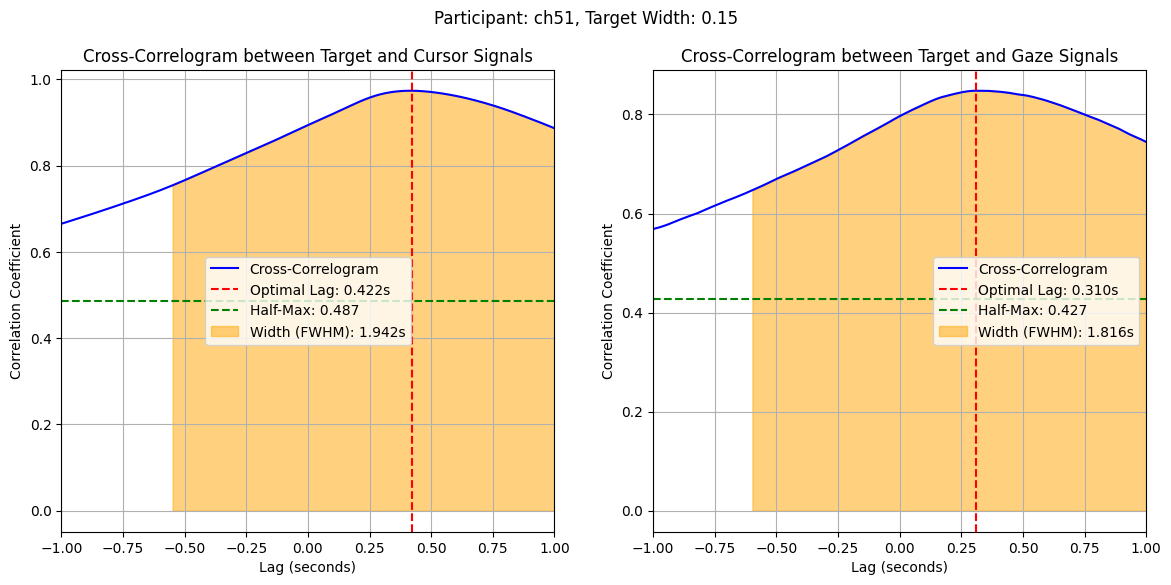

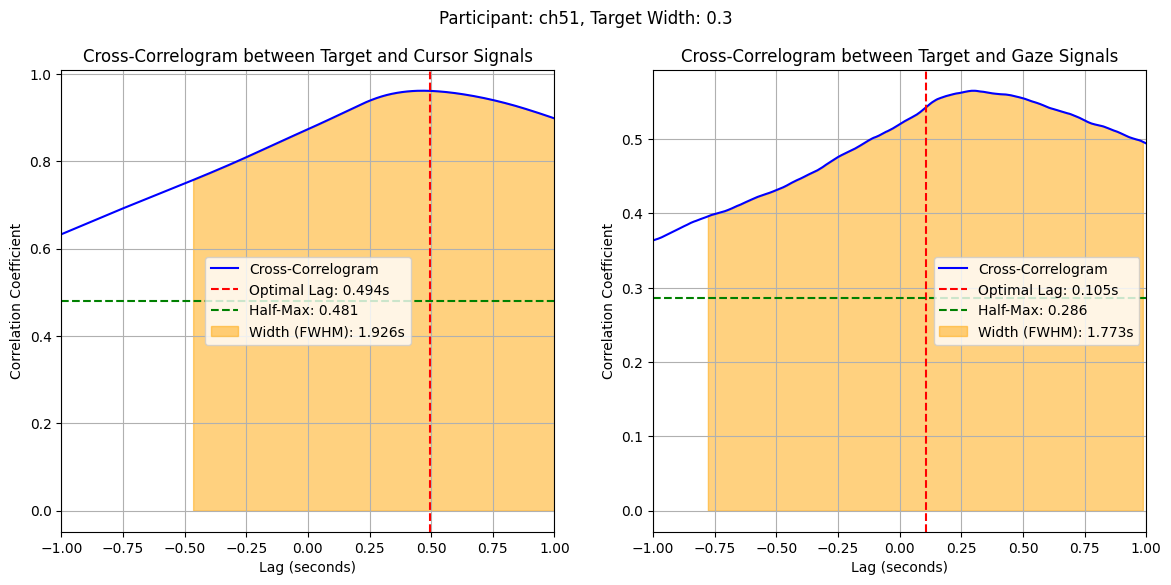

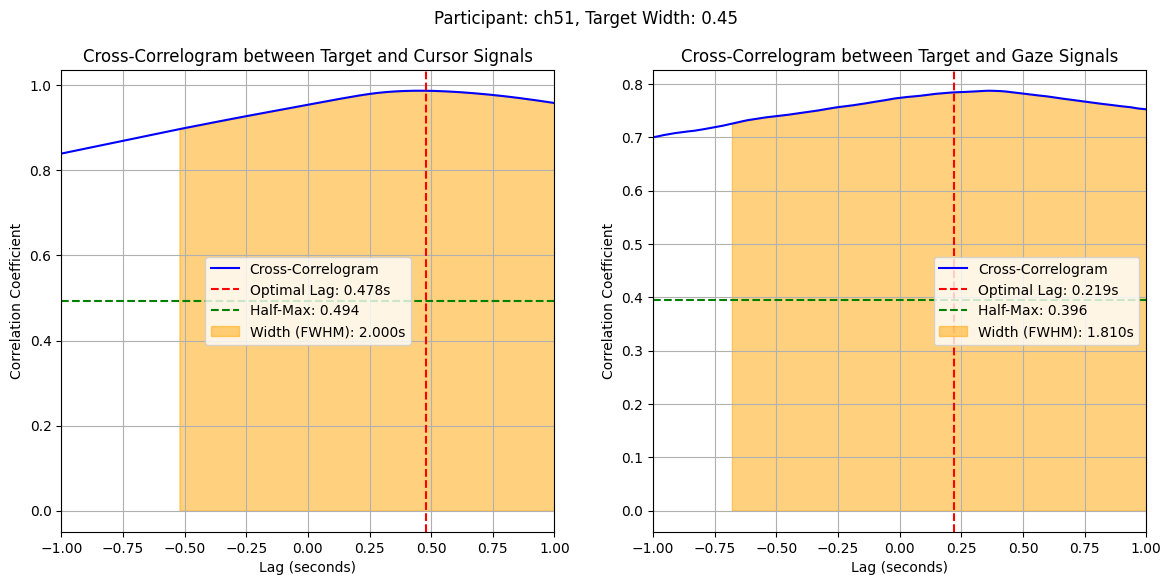

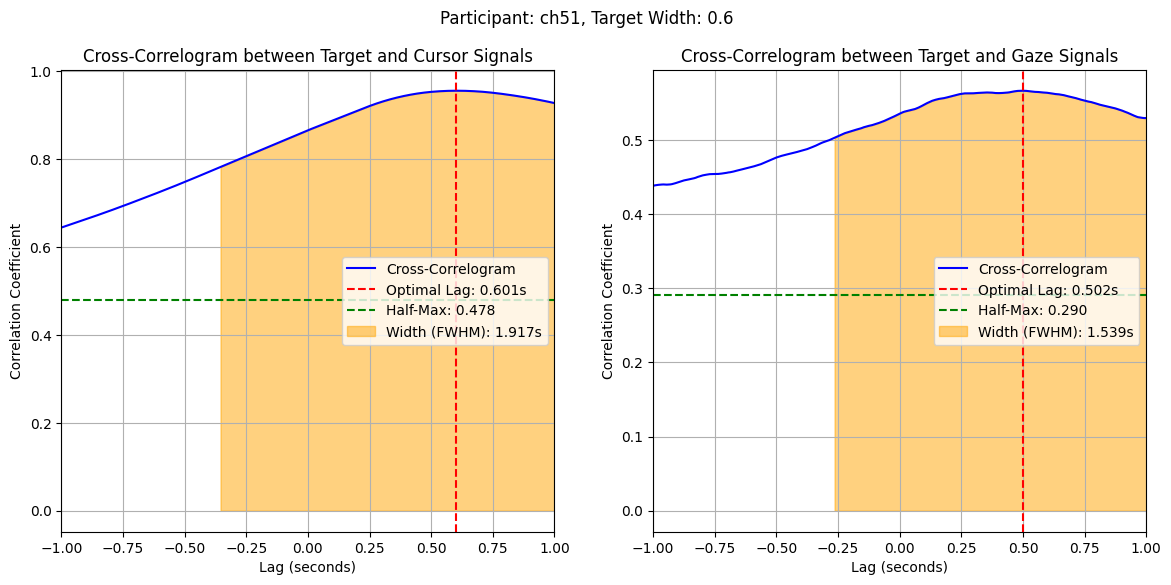

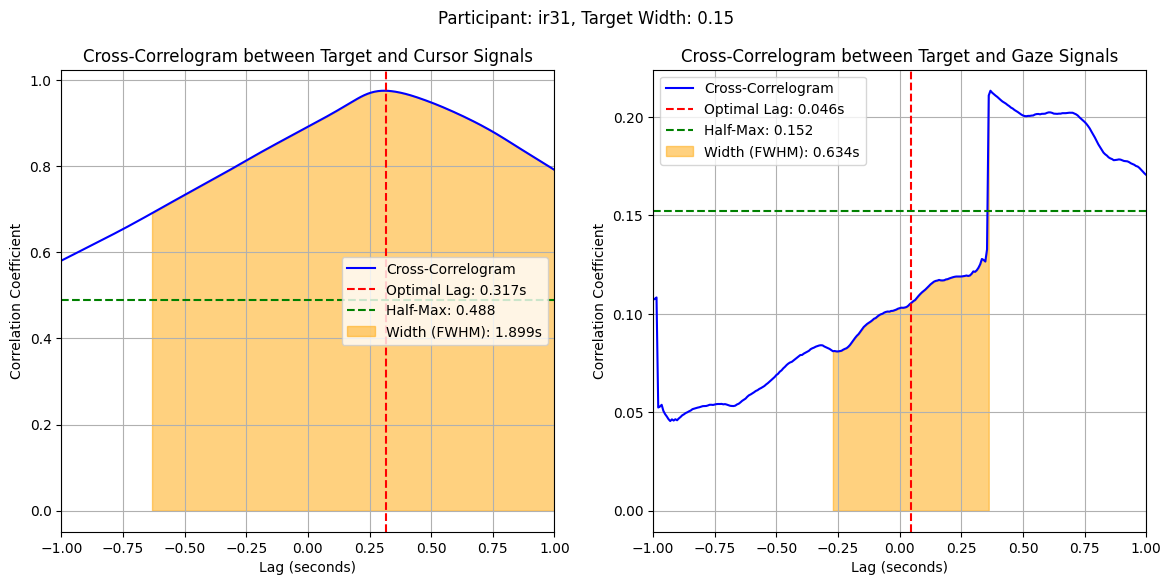

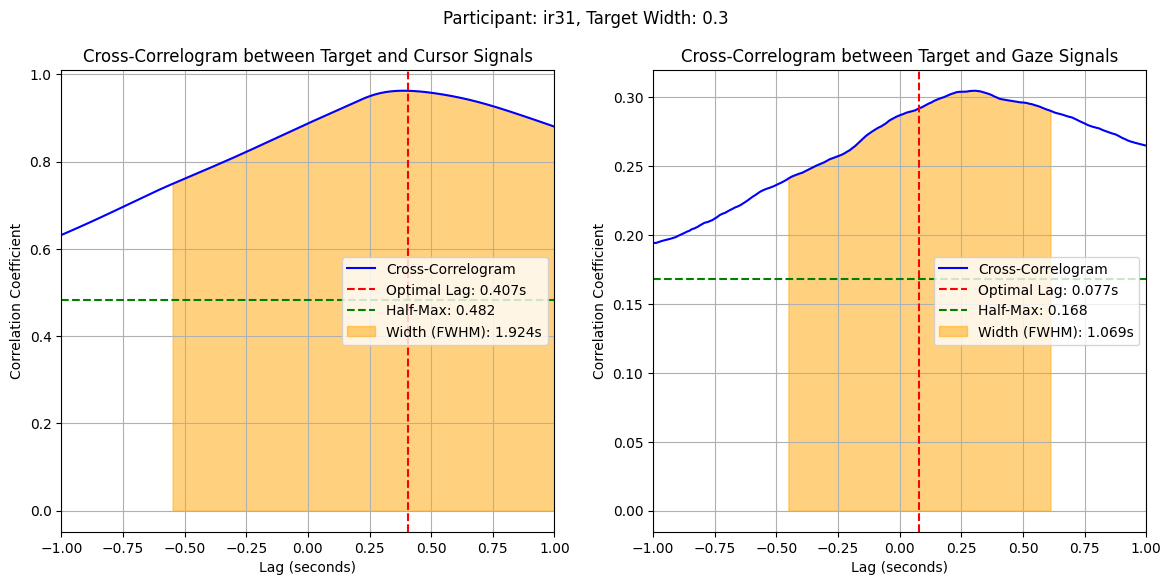

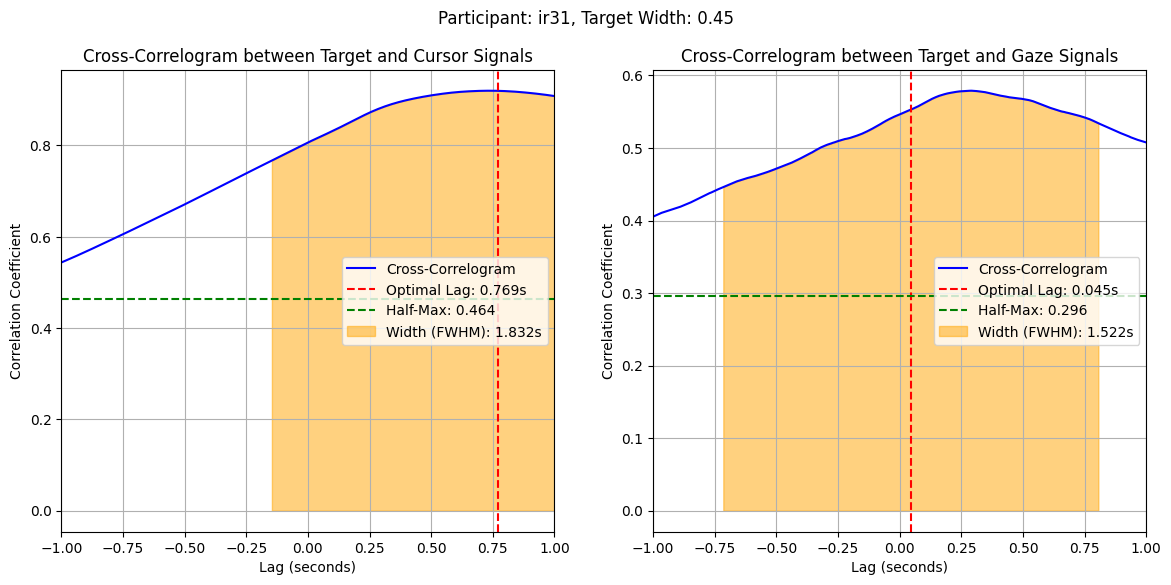

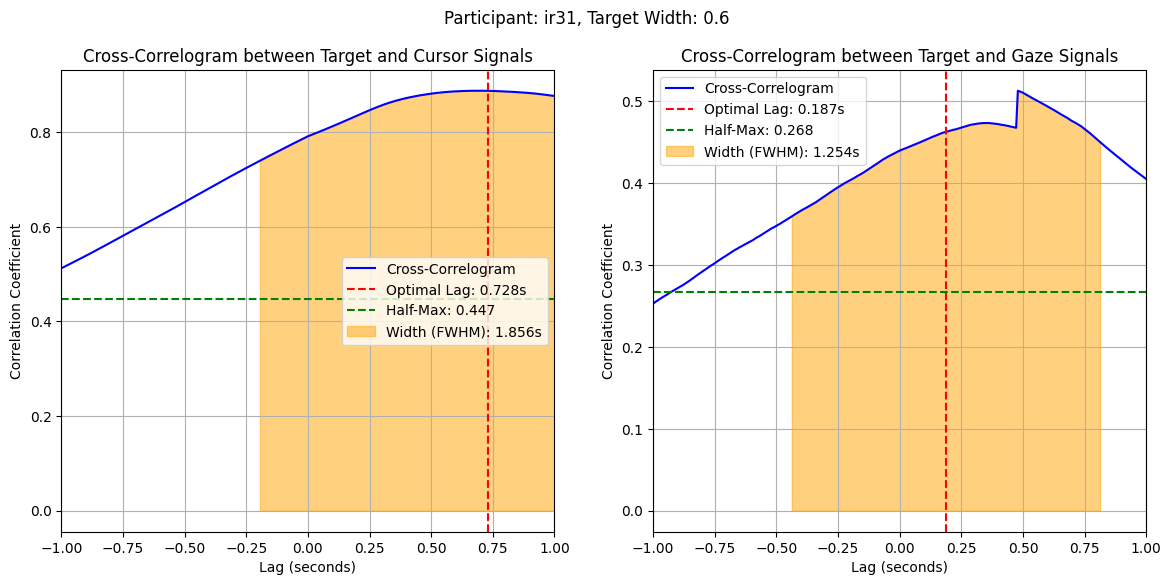

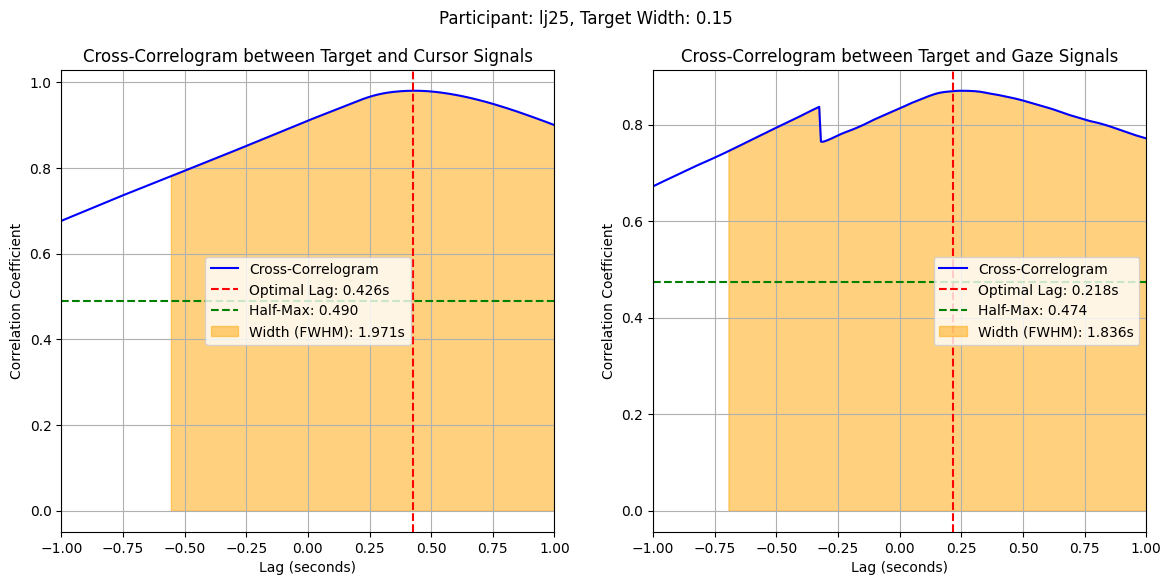

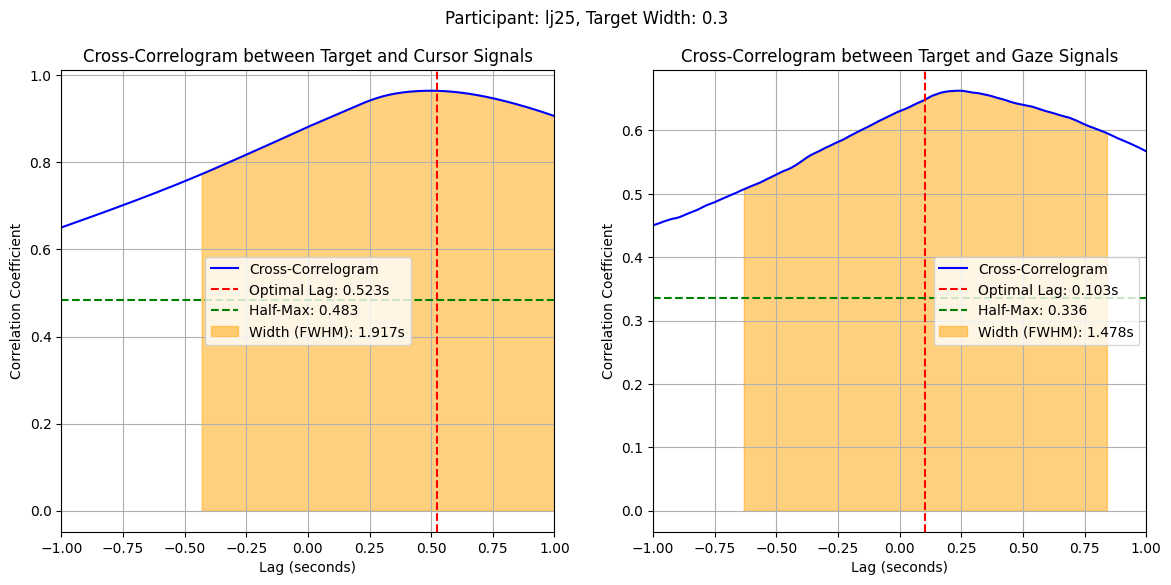

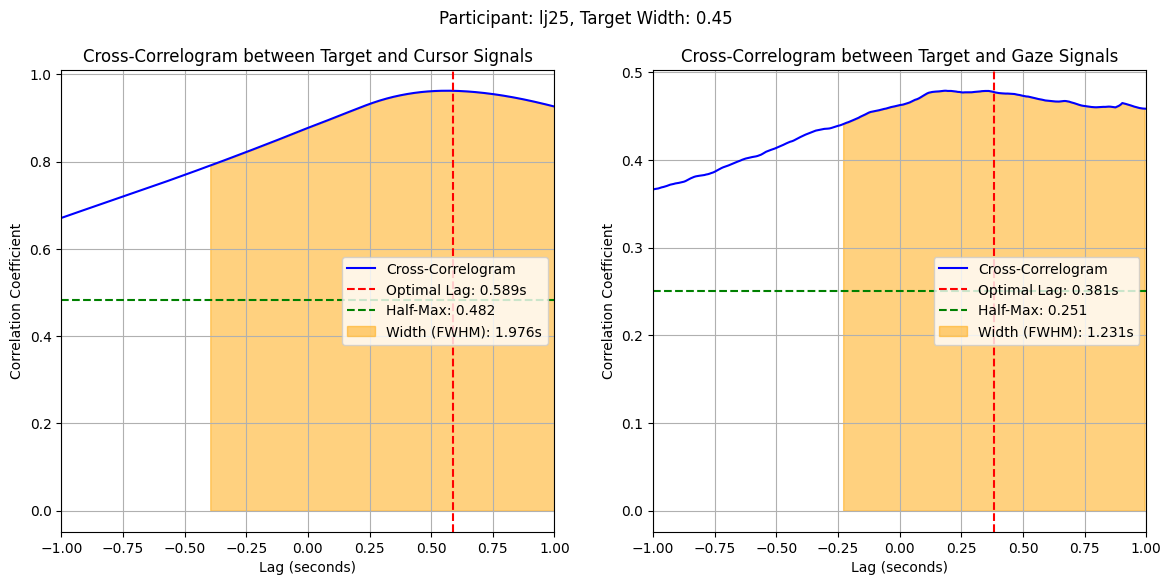

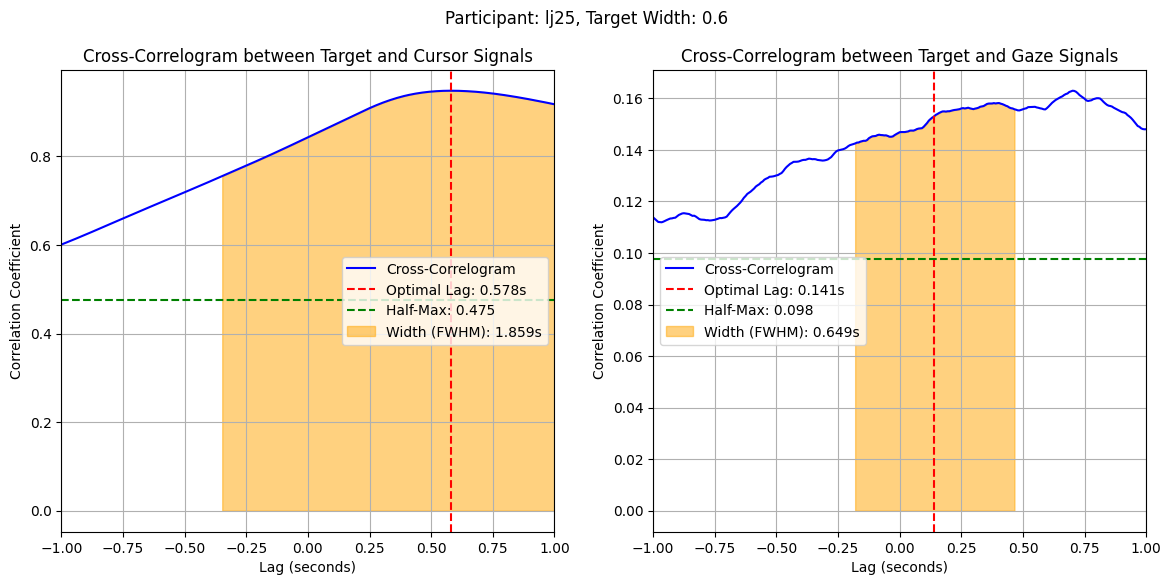

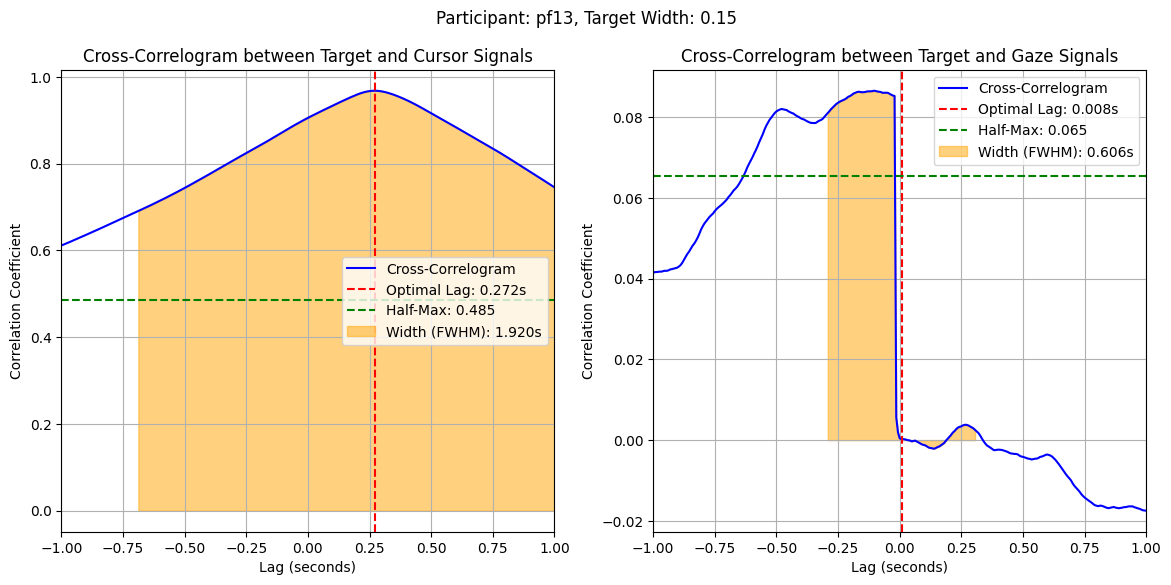

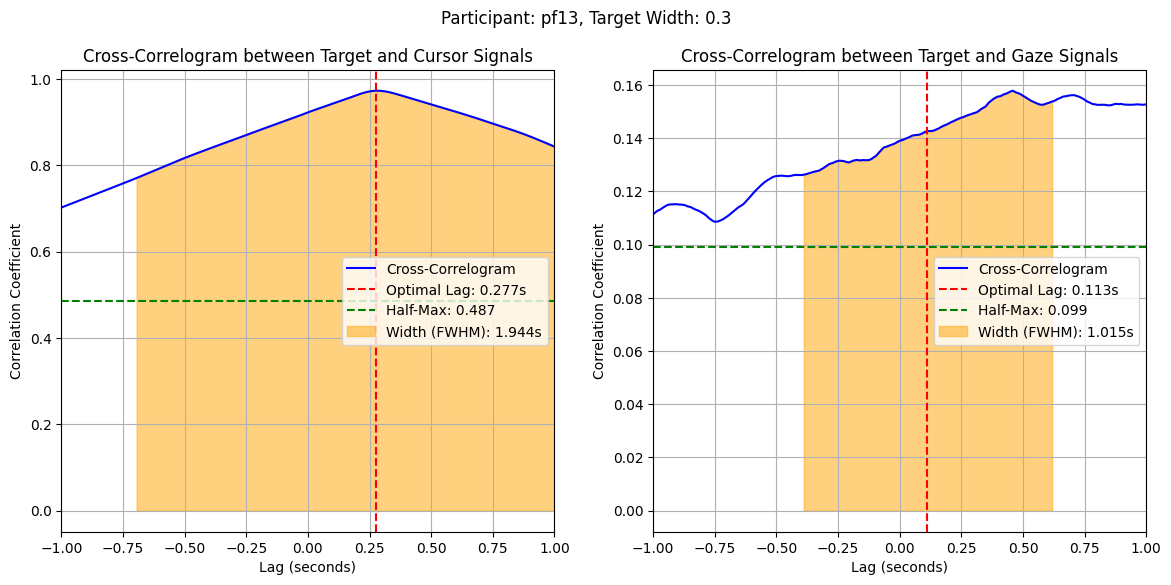

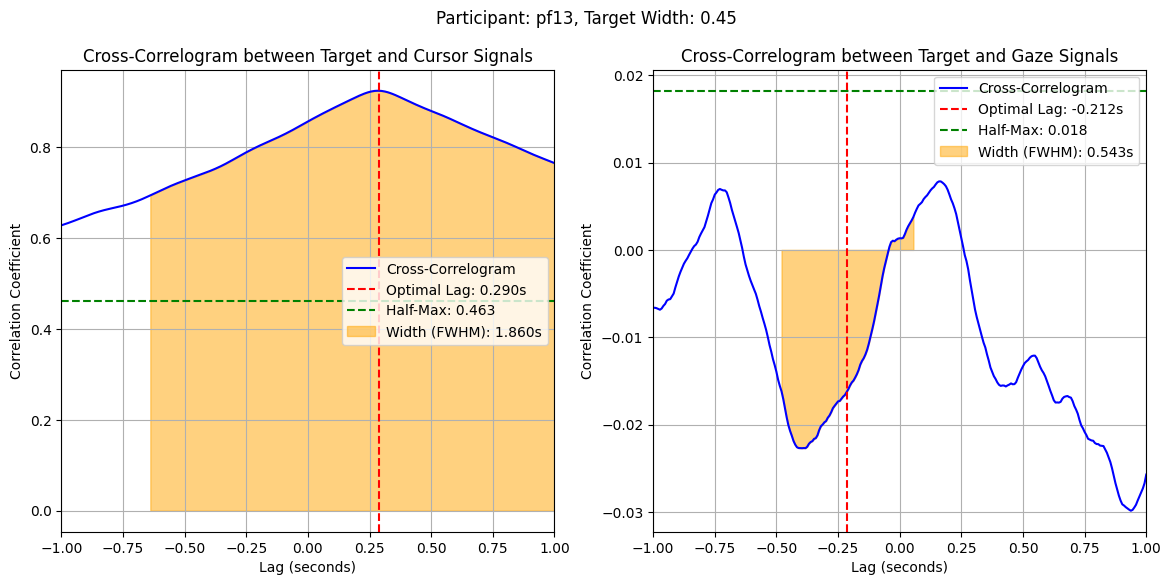

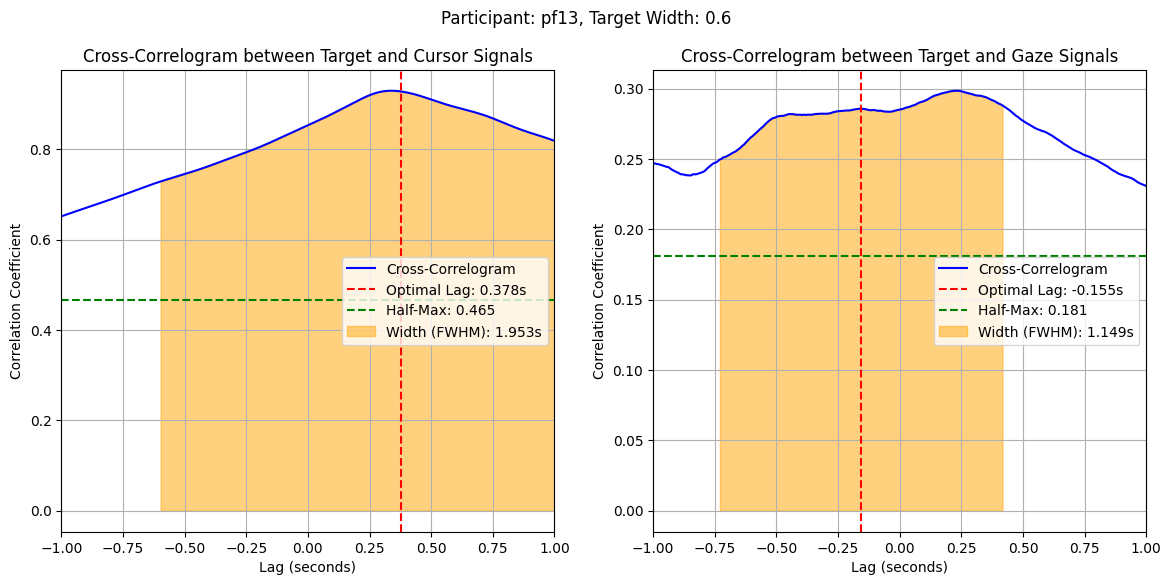

In [106]:
# plot cross correlogram for all participants and target widths (cursor metrics)
for participant_id, participant_data in continuous_metrics.groupby('participant_id'):
    for target_width, row in participant_data.groupby('target_width'):
        # to fix. plots only show the cursor metrics, gaze subplot is empty
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        plt.suptitle(f'Participant: {participant_id}, Target Width: {target_width}')
        plot_cross_correlogram(
            fig = fig,
            axes = axes[0],
            lags = row['lags_cursor'].iloc[0],
            correlation_scores = row['correlation_scores_cursor'].iloc[0],
            optimal_lag_seconds = row['lag_cursor'].iloc[0],
            peak_correlation = row['peak_cursor'].iloc[0],
            width = row['width_cursor'].iloc[0],
            signal_name='Cursor'
        )
        # plot gaze next to cursor for comparison
        plot_cross_correlogram(
            fig = fig,
            axes = axes[1],
            lags = row['lags_gaze'].iloc[0],
            correlation_scores = row['correlation_scores_gaze'].iloc[0],
            optimal_lag_seconds = row['lag_gaze'].iloc[0],
            peak_correlation = row['peak_gaze'].iloc[0],
            width = row['width_gaze'].iloc[0],
            signal_name='Gaze'
        )
        plt.show()

# example_participant = continuous_metrics['participant_id'].iloc[8]
# example_target_width = continuous_metrics['target_width'].iloc[0]
# example_row = continuous_metrics[
#     (continuous_metrics['participant_id'] == example_participant) &
#     (continuous_metrics['target_width'] == example_target_width)
# ].iloc[0]
# plot_cross_correlogram(
#     example_row['lags_cursor'],
#     example_row['correlation_scores_cursor'],
#     example_row['lag_cursor'],
#     example_row['peak_cursor'],
#     example_row['width_cursor']
# )